In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import re
import uuid
from scipy import misc
from PIL import Image
import sys
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import time
from pathlib import Path

from IO import (
    read, write, readPFM, writePFM, readFlow, 
    readImage, writeImage, writeFlow, readFloat, writeFloat
)

from models import FlowNetSimple, DownBlock
from datasets import FlyingChairsDataset, TestOpticalFlowDataset
from utils import (
    flow_to_rgb, epe_loss, visualize_sample, 
    plot_batch_losses, plot_avg_train_loss,
    visualize_val_sample_from_paths,
    evaluate_model, center_crop_to_multiple,
    evaluate_model_ferneback
)

DATA_DIR = "./data"
PREPARED_TEST_DIR = "./evaluation_data"
TRAIN_SPLIT = 0.8
BATCH_SIZE = 8

NUM_EPOCHS = 127
LEARNING_RATE = 1e-4
CHECKPOINT_DIR = "./checkpoints"
NUM_CHECKPOINTS_TO_KEEP = 5

START_CHECKPOINT = "./checkpoints/flownet_epoch3_step6864.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device = DEVICE


In [2]:

def test_model(model):
    model = model.to(device)

    if TEST_CHECKPOINT:
        if os.path.isfile(TEST_CHECKPOINT):
            ckpt = torch.load(TEST_CHECKPOINT, map_location=device)
            model.load_state_dict(ckpt["model_state"])
            print(f"Loaded checkpoint for testing: {TEST_CHECKPOINT}")
        else:
            print(f"TEST_CHECKPOINT '{TEST_CHECKPOINT}' not found, using current model weights.")
    else:
        print("No TEST_CHECKPOINT set, using current model weights.")

    model.eval()

def get_indices():
    files = os.listdir(DATA_DIR)
    indices = sorted(set(f.split('_')[0] for f in files if f.endswith("_img1.ppm")))
    return indices

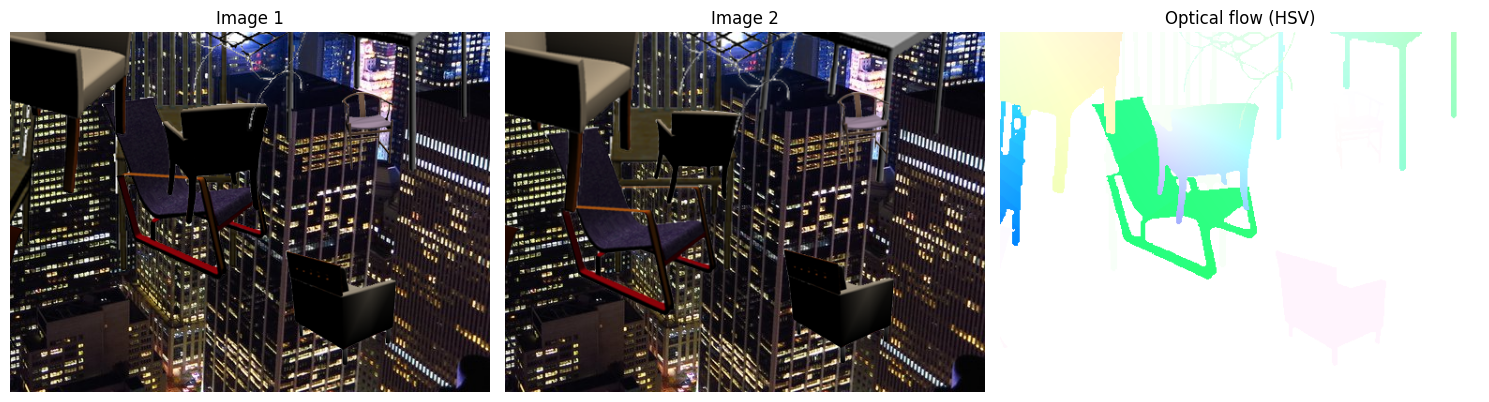

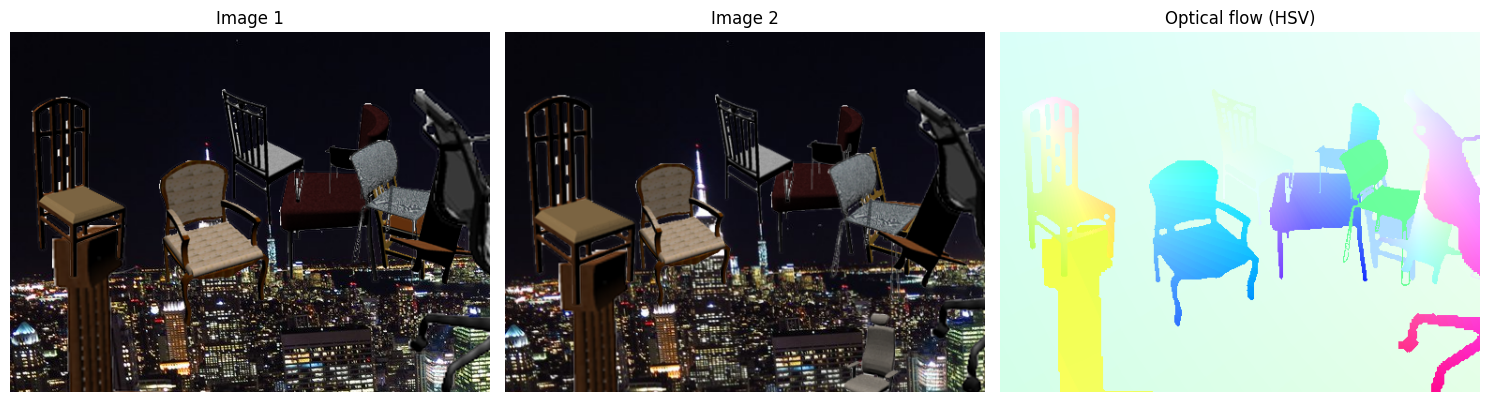

In [3]:
visualize_sample("00008", DATA_DIR)
visualize_sample("00009", DATA_DIR)

In [4]:

all_indices = get_indices()
num_train = int(len(all_indices) * TRAIN_SPLIT)

train_indices = all_indices[:num_train]
val_indices = all_indices[num_train:]

train_dataset = FlyingChairsDataset(train_indices, data_dir=DATA_DIR)
val_dataset = FlyingChairsDataset(val_indices, data_dir=DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
train_batch_losses = []
val_batch_losses = []
model = FlowNetSimple().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train():
    start_epoch = 0
    global_step = 0
    checkpoint_paths = []

    if START_CHECKPOINT and os.path.isfile(START_CHECKPOINT):
        ckpt = torch.load(START_CHECKPOINT, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt.get("epoch", 0) + 1
        global_step = ckpt.get("global_step", 0)
        checkpoint_paths.append(START_CHECKPOINT)
        print(f"Resumed from {START_CHECKPOINT} at epoch {start_epoch}, step {global_step}")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        for batch_idx, (img1, img2, flow_gt) in enumerate(train_loader):
            batch_start = time.time()

            img1 = img1.to(device)
            img2 = img2.to(device)
            flow_gt = flow_gt.to(device)

            x = torch.cat([img1, img2], dim=1)

            optimizer.zero_grad()
            pred_flow = model(x)
            loss = epe_loss(pred_flow, flow_gt)
            loss.backward()
            optimizer.step()

            train_batch_losses.append(loss.item())

            batch_time = time.time() - batch_start
            running_loss += loss.item()
            global_step += 1

            print(
                f"  [Train] Batch {batch_idx+1}/{len(train_loader)} "
                f"Step {global_step} "
                f"Loss {loss.item():.4f} "
                f"Time {batch_time:.3f}s"
            )

        avg_train_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1} average train loss: {avg_train_loss:.4f}")

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for img1, img2, flow_gt in val_loader:
                img1 = img1.to(device)
                img2 = img2.to(device)
                flow_gt = flow_gt.to(device)

                x = torch.cat([img1, img2], dim=1)
                pred_flow = model(x)
                loss = epe_loss(pred_flow, flow_gt)
                val_loss_sum += loss.item()
                val_batch_losses.append(loss.item())

        avg_val_loss = val_loss_sum / max(1, len(val_loader))

        print(f"Epoch {epoch+1} average val loss: {avg_val_loss:.4f}")

        ckpt_path = os.path.join(
            CHECKPOINT_DIR, f"flownet_epoch{epoch+1}_step{global_step}.pt"
        )
        torch.save(
            {
                "epoch": epoch,
                "global_step": global_step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            },
            ckpt_path,
        )
        checkpoint_paths.append(ckpt_path)

        # keep only the last NUM_CHECKPOINTS_TO_KEEP checkpoints
        if len(checkpoint_paths) > NUM_CHECKPOINTS_TO_KEEP:
            old = checkpoint_paths.pop(0)
            if os.path.exists(old):
                os.remove(old)
                print(f"Removed old checkpoint: {old}")

        print(f"Saved checkpoint: {ckpt_path}")

train()


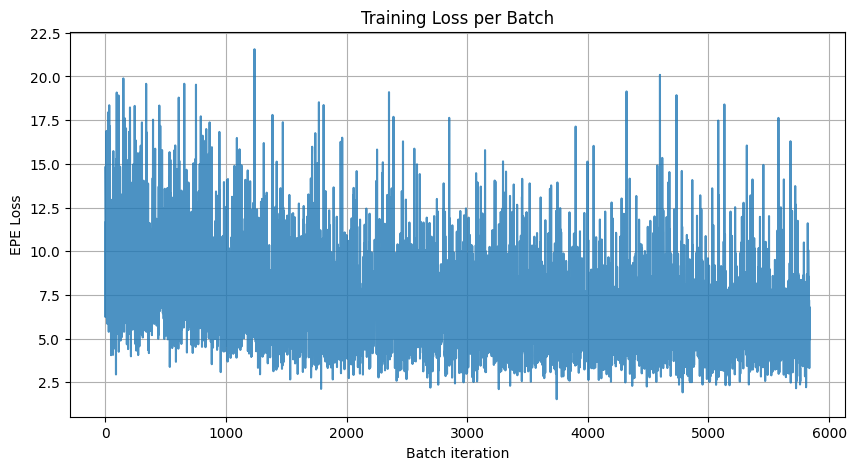

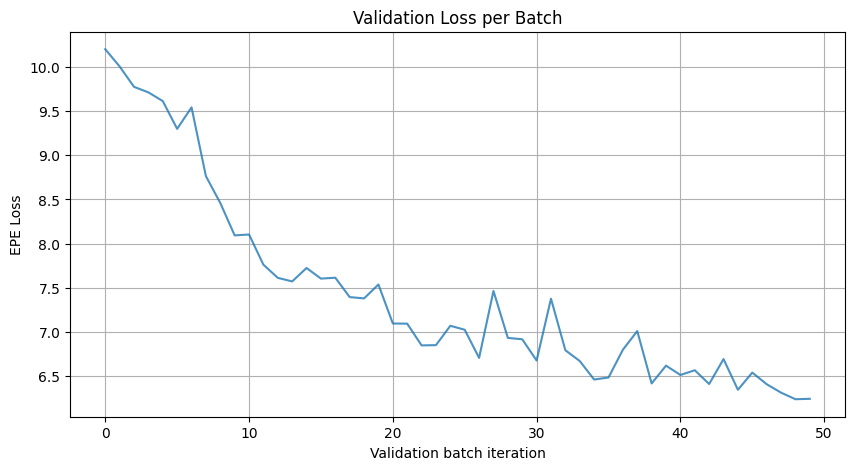

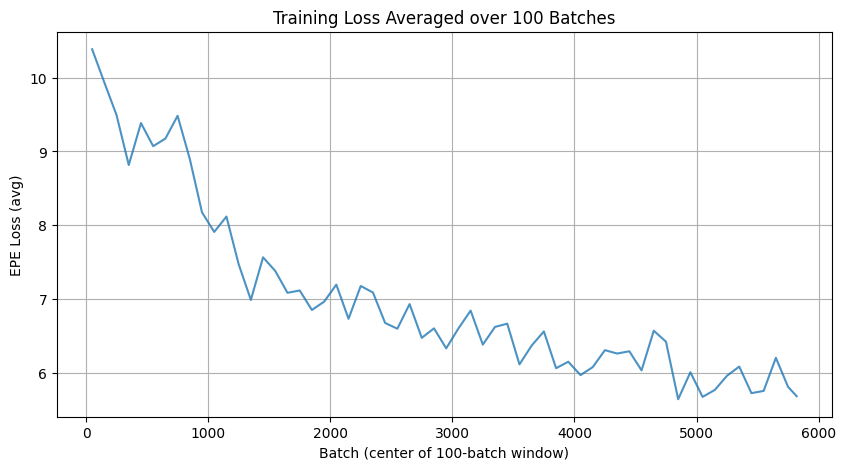

In [5]:
train_batch_losses = np.loadtxt("train_losses.txt")
val_batch_losses = np.loadtxt("val_losses.txt")

plot_batch_losses(train_batch_losses, val_batch_losses)
plot_avg_train_loss(train_batch_losses, window_size=100)


In [6]:
TEST_CHECKPOINT = "./checkpoints/flownet_epoch50_step114400.pt"
model_test = FlowNetSimple().to(device)
test_model(model_test)

print(model_test)

Loaded checkpoint for testing: ./checkpoints/flownet_epoch50_step114400.pt
FlowNetSimple(
  (down1): DownBlock(
    (conv1): Conv2d(6, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv1): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (do

Loaded checkpoint for testing: ./checkpoints/flownet_epoch50_step114400.pt


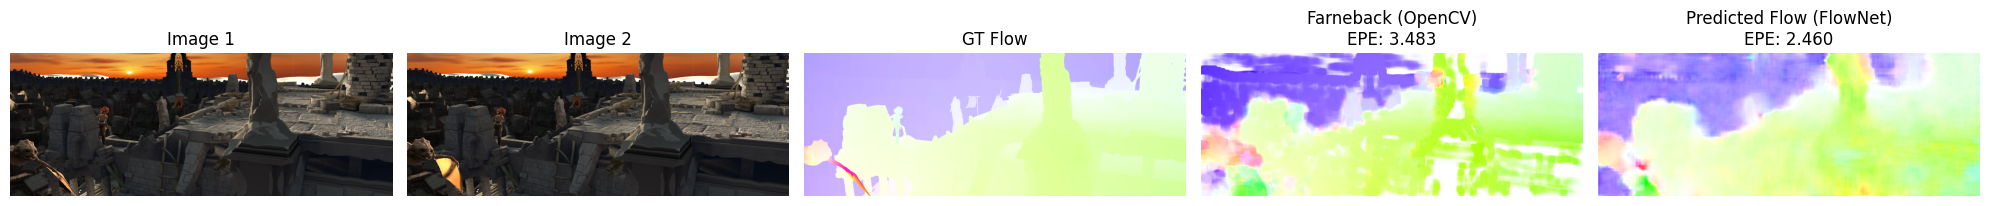

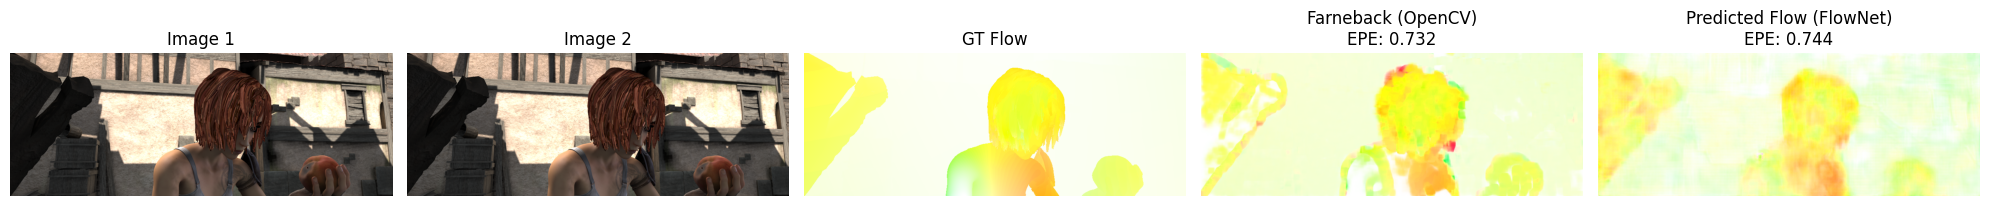

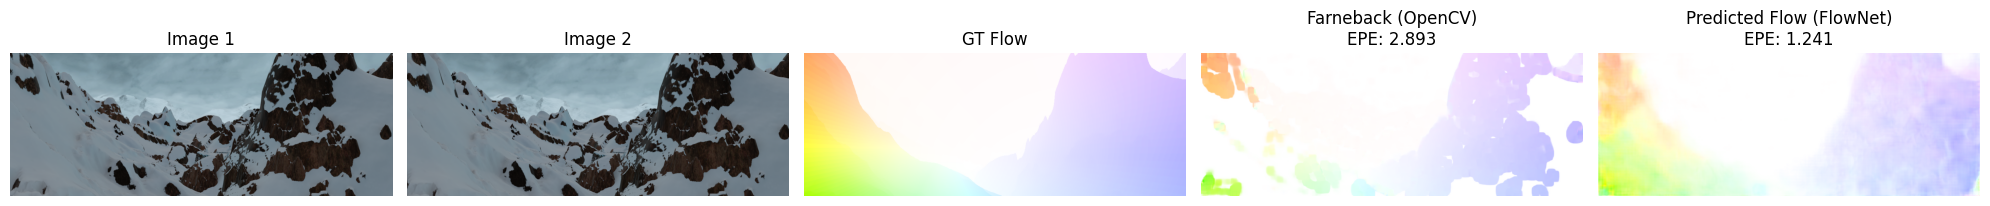

In [ ]:

img1 = "./test_data/clean/temple_2/frame_0004.png"
img2 = "./test_data/clean/temple_2/frame_0005.png"
flow = "./test_data/flow/temple_2/frame_0004.flo"

test2_img1 = "./test_data/clean/alley_1/frame_0001.png"
test2_img2 = "./test_data/clean/alley_1/frame_0002.png"
test2_flow = "./test_data/flow/alley_1/frame_0001.flo"

test3_img1 = "./test_data/clean/mountain_1/frame_0005.png"
test3_img2 = "./test_data/clean/mountain_1/frame_0006.png"
test3_flow = "./test_data/flow/mountain_1/frame_0005.flo"



farneback_epe1, pred_epe1 = visualize_val_sample_from_paths(model_test, img1, img2, flow, device )
farneback_epe2, pred_epe2 = visualize_val_sample_from_paths(model_test, test2_img1, test2_img2, test2_flow, device )
farneback_epe3, pred_epe3 = visualize_val_sample_from_paths(model_test, test3_img1, test3_img2, test3_flow, device )



In [7]:
test_dataset = TestOpticalFlowDataset(PREPARED_TEST_DIR, skip_corrupted=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(test_loader))
img1_batch, img2_batch, flow_batch = batch

Skipping corrupted sample 000280: Flow file evaluation_data/000280_flow.flo: Data size mismatch. Expected 892928 values (w=1024, h=436), but got 557053 values.
Skipped 1 corrupted samples
TestOpticalFlowDataset: 1017 valid samples found in evaluation_data


In [8]:
FERNEBACK_PARAMS = {
    "pyr_scale": 0.5, # lower -> blurry fast motion
    "levels": 3, # lower -> detect small motions but faster
    "winsize": 15, # lower -> noisy but sharper
    "iterations": 1, # stronger colors (practicall), theoretically higher is better
    "poly_n": 5, # higher -> smoother motion blobs
    "poly_sigma": 1.0, # higher -> blurry
    "flags": 0 # smoothing using average filter for smoothing
}
print(FERNEBACK_PARAMS)

{'pyr_scale': 0.5, 'levels': 3, 'winsize': 15, 'iterations': 1, 'poly_n': 5, 'poly_sigma': 1.0, 'flags': 0}


In [ ]:
avg_epe, epe_array = evaluate_model(model_test, test_loader, device)

In [ ]:
avg_epe_ferneback, epe_array_ferneback = evaluate_model_ferneback(test_loader, device)


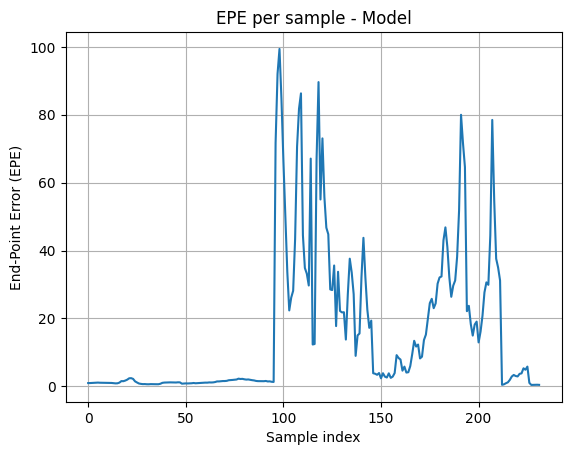

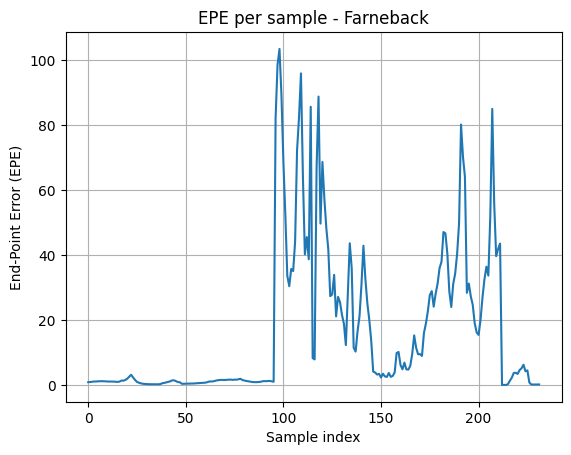

In [15]:
epe_array = np.array(epe_array)
epe_array_ferneback = np.array(epe_array_ferneback)

# -------- Chart 1: Your model --------
plt.figure()
plt.plot(epe_array)
plt.title("EPE per sample - Model")
plt.xlabel("Sample index")
plt.ylabel("End-Point Error (EPE)")
plt.grid(True)
plt.show()


# -------- Chart 2: Farneback --------
plt.figure()
plt.plot(epe_array_ferneback)
plt.title("EPE per sample - Farneback")
plt.xlabel("Sample index")
plt.ylabel("End-Point Error (EPE)")
plt.grid(True)
plt.show()

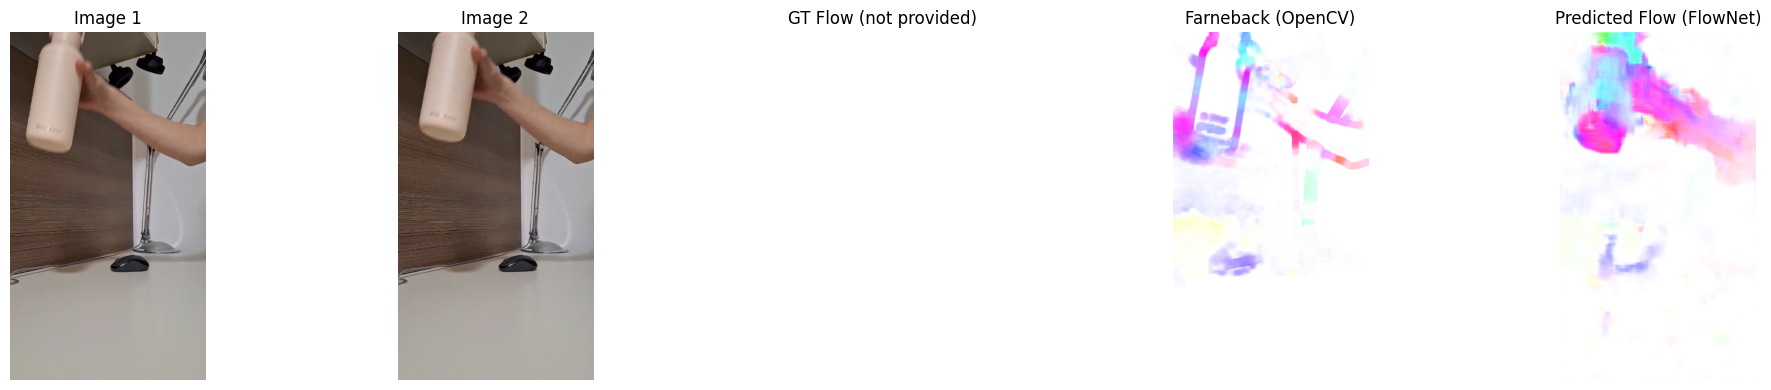

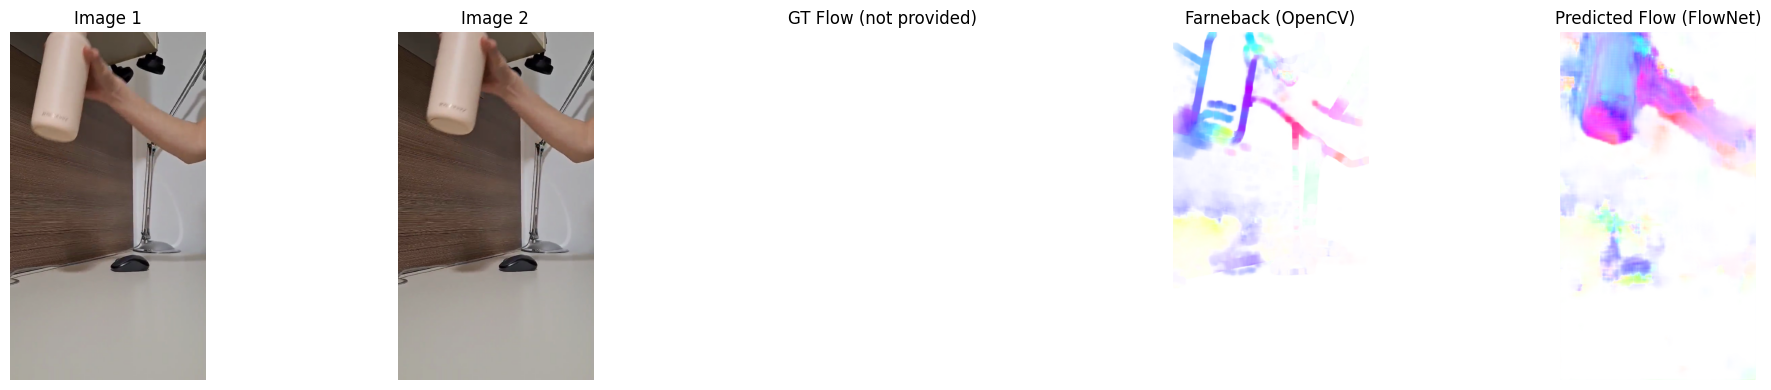

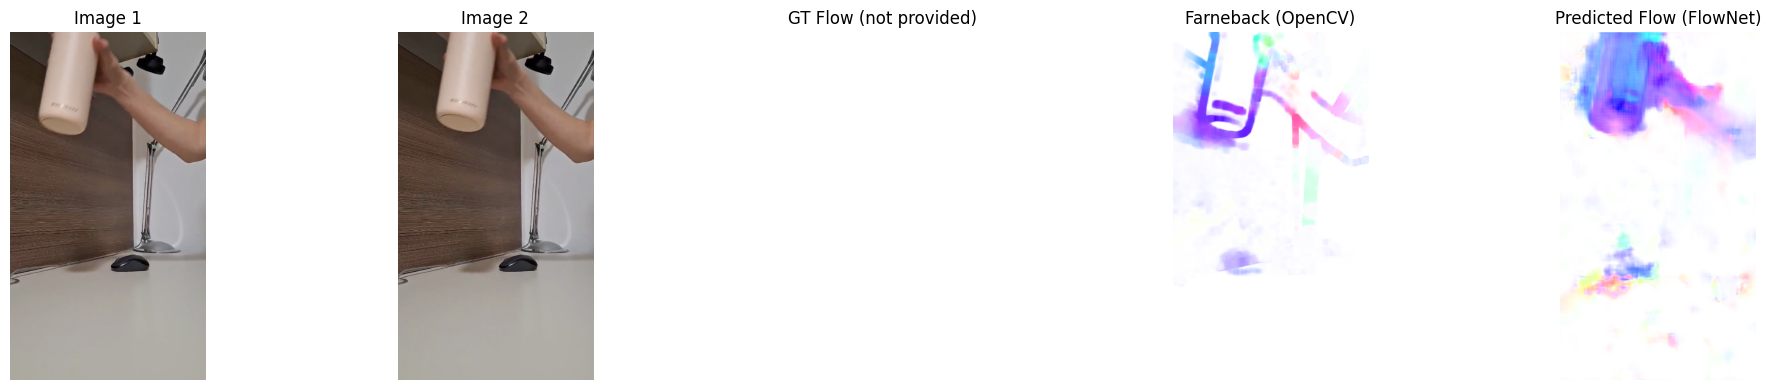

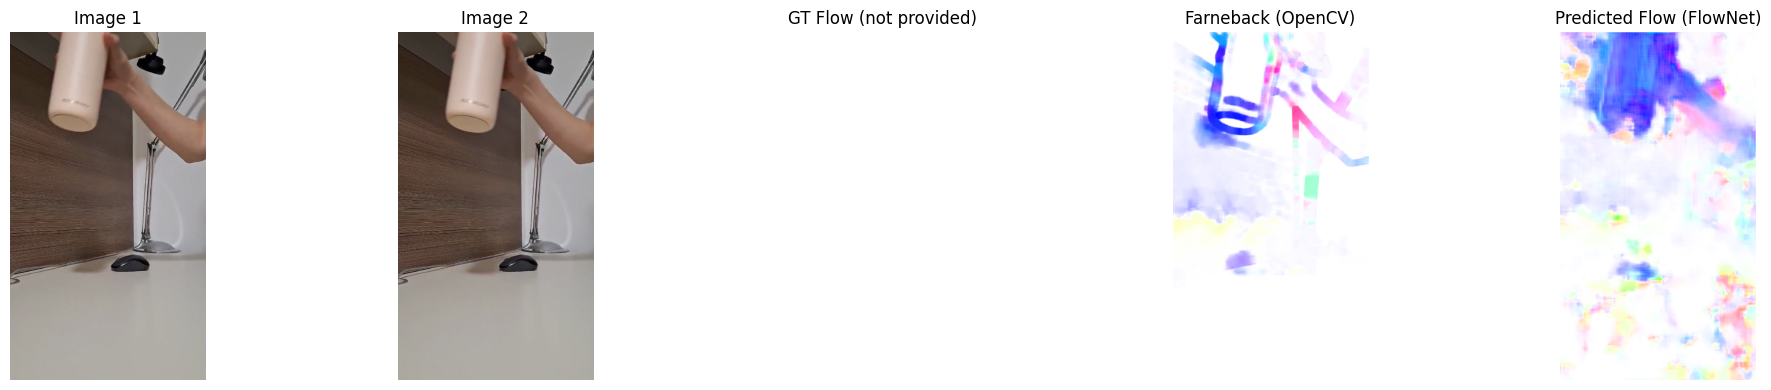

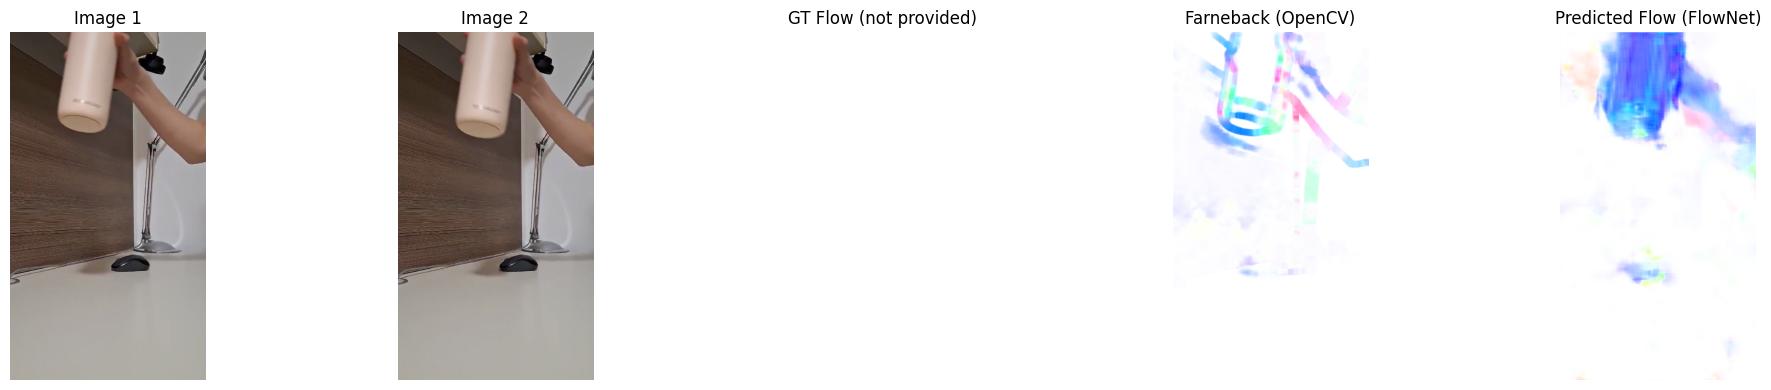

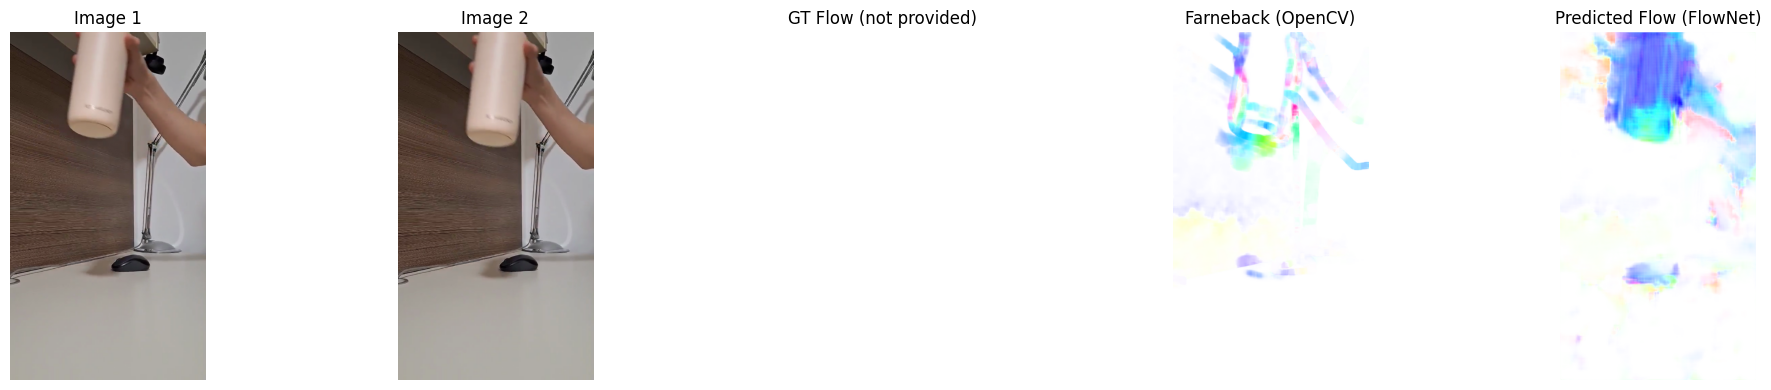

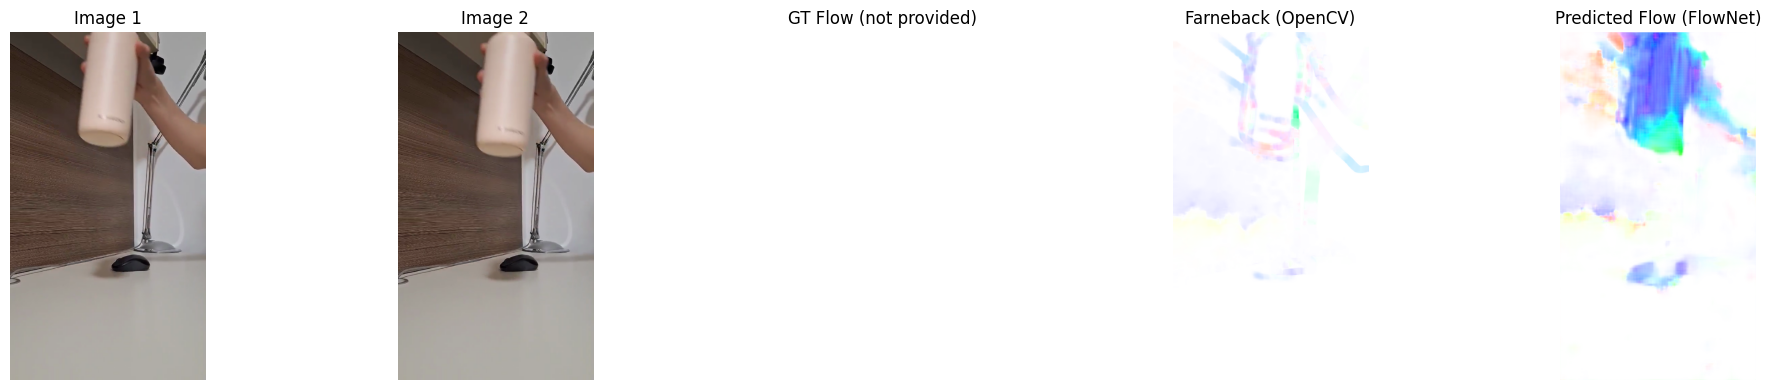

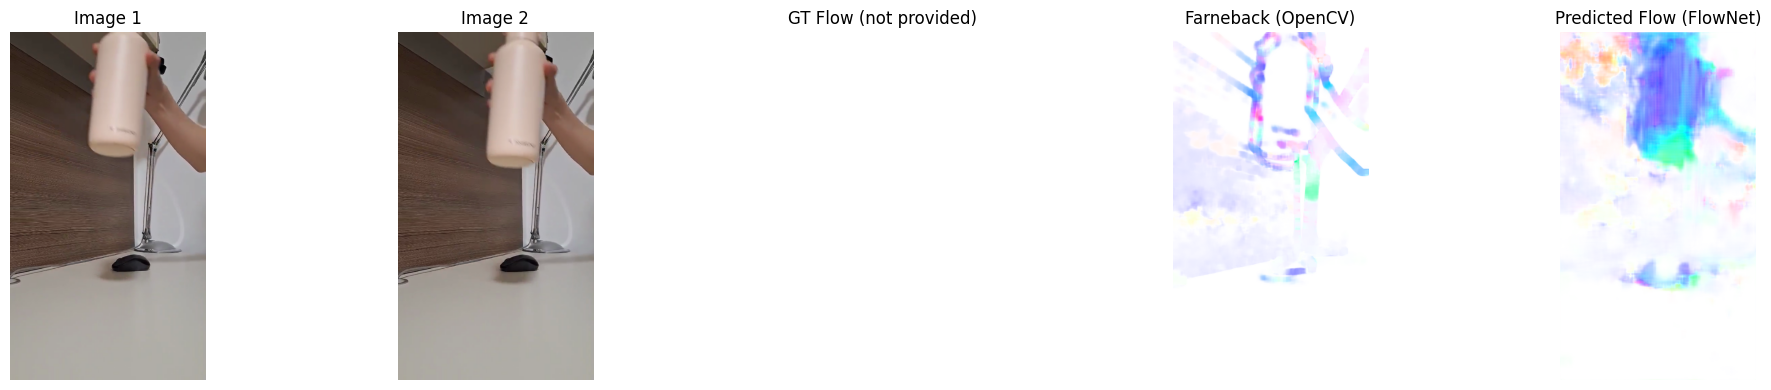

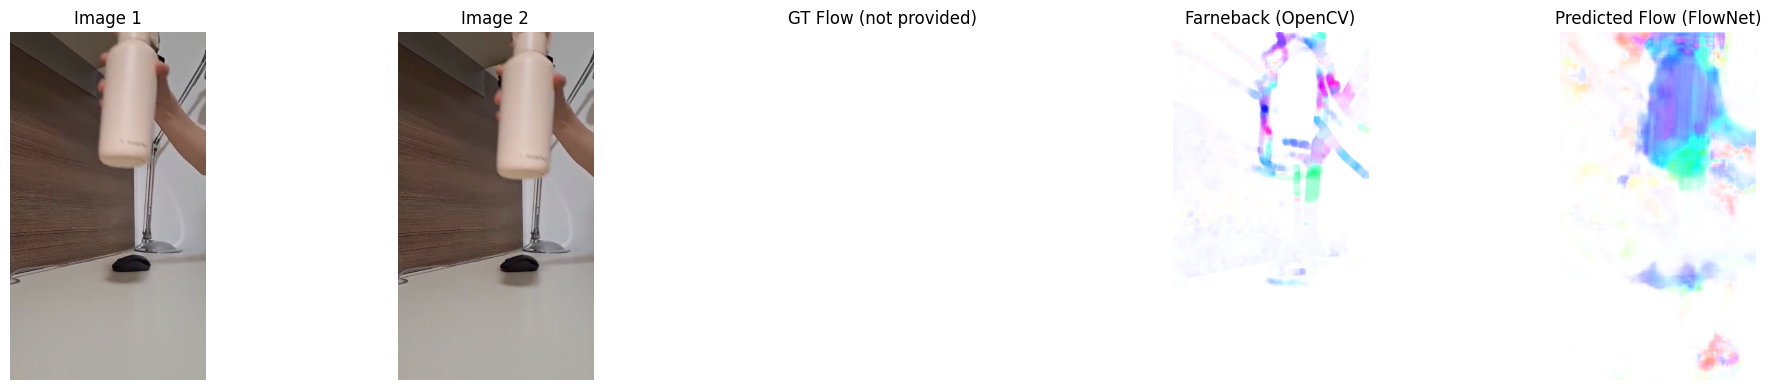

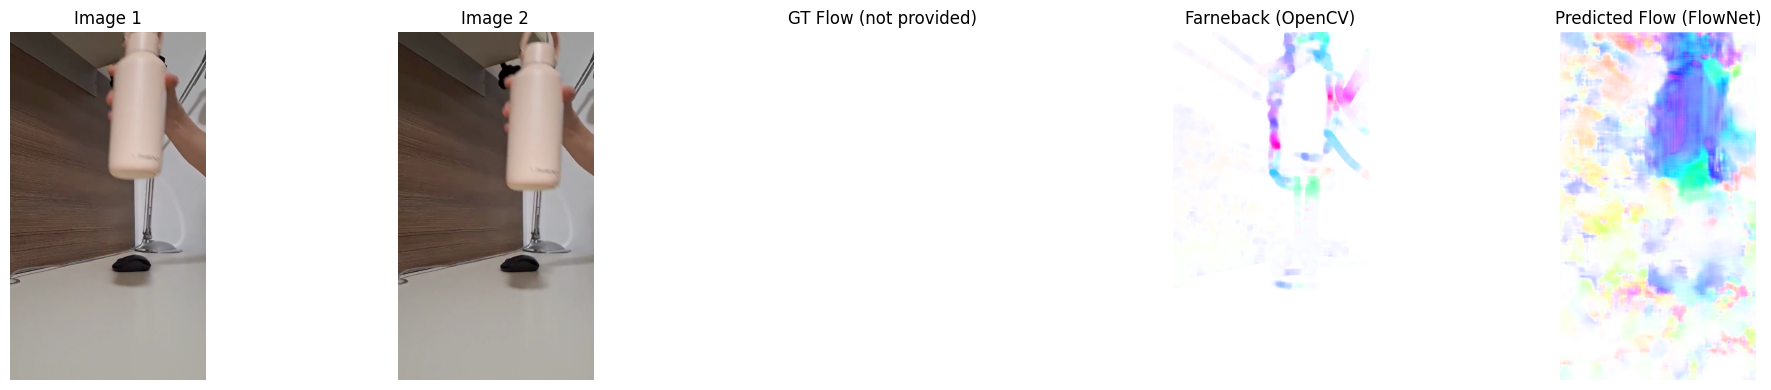

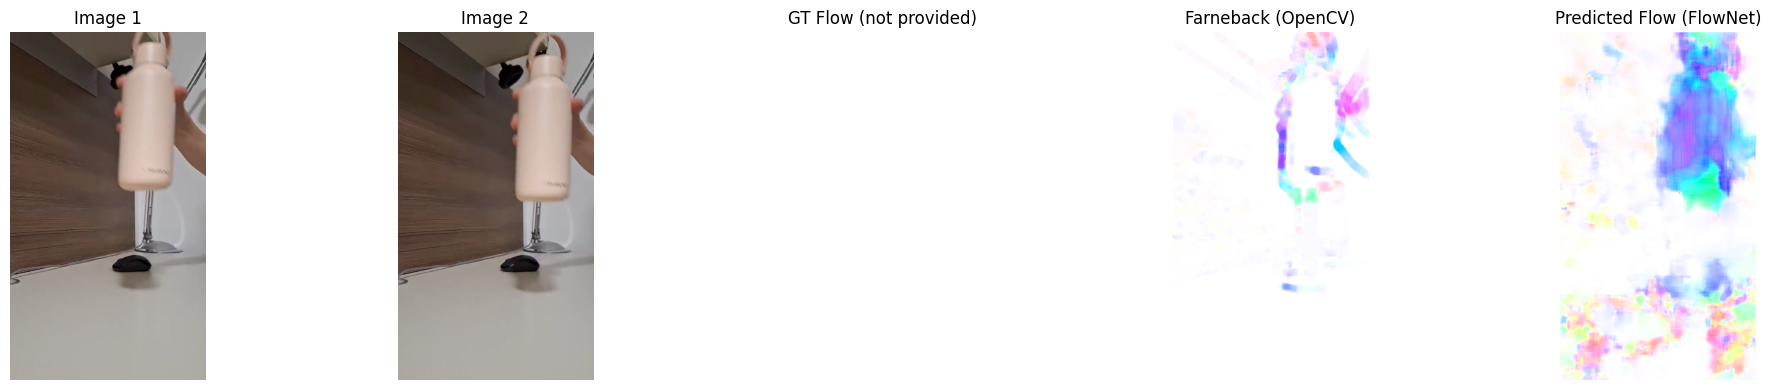

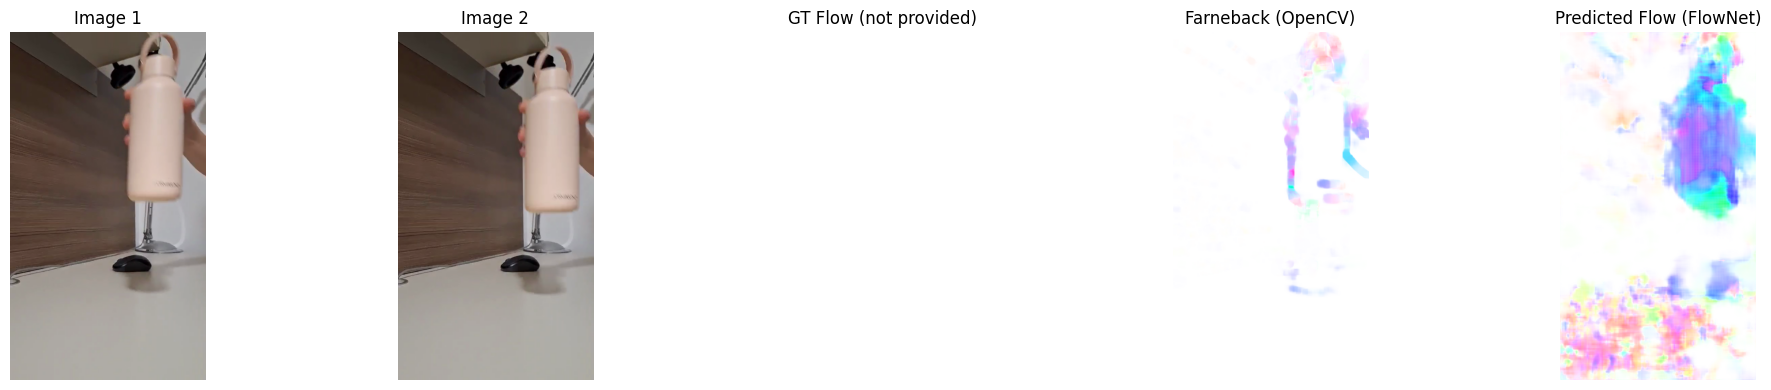

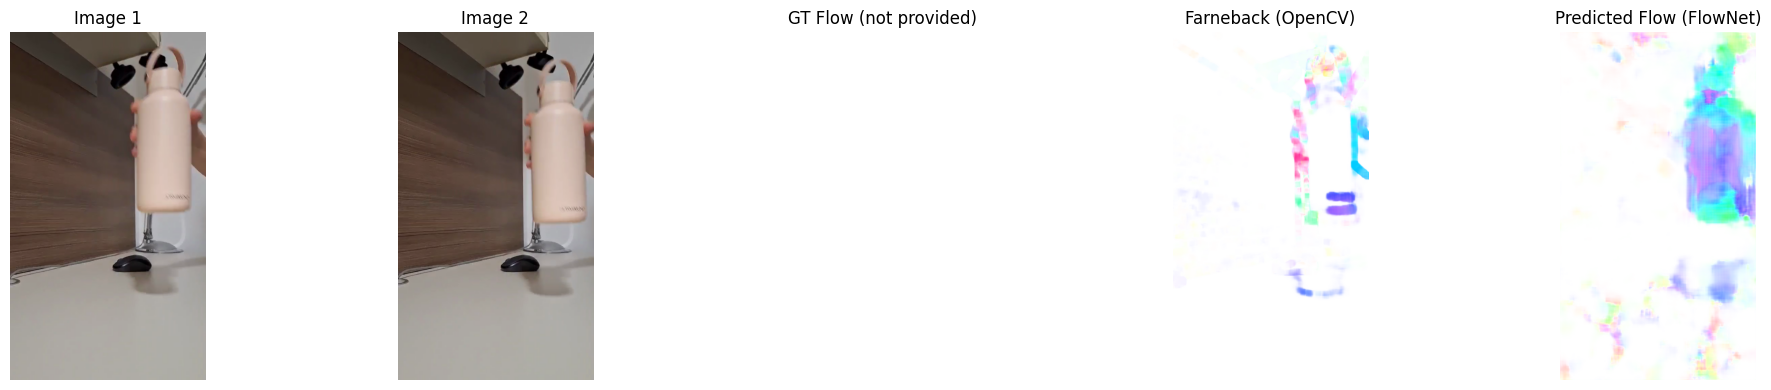

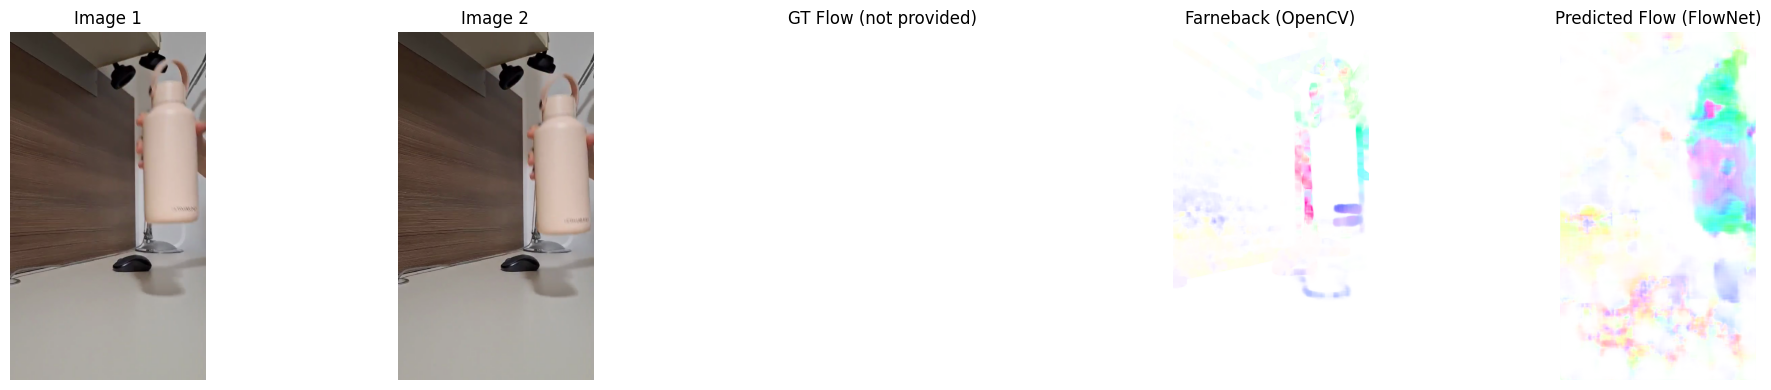

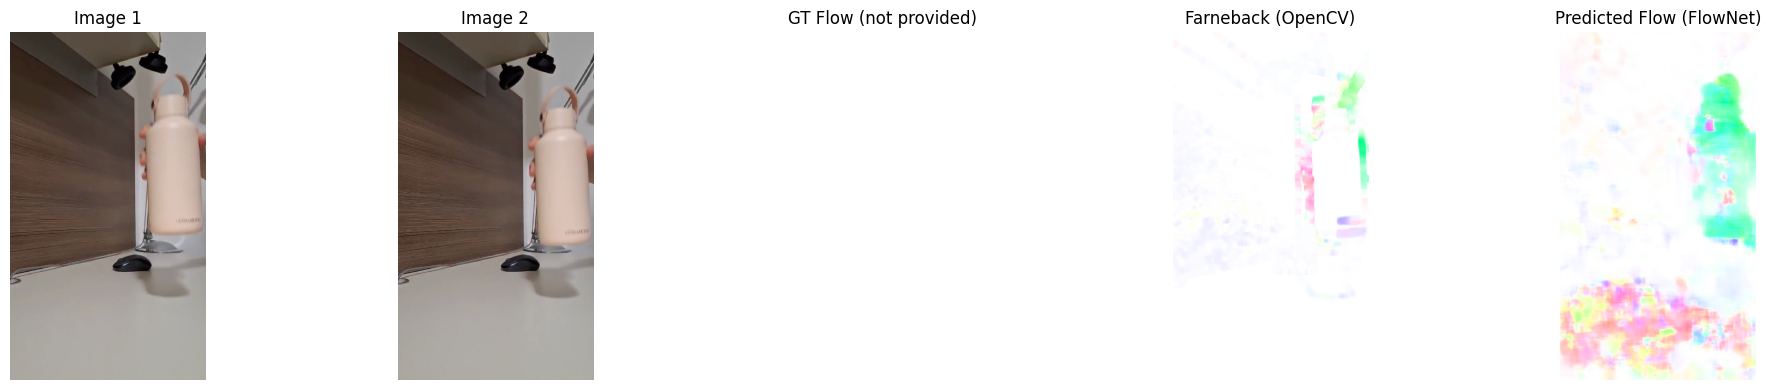

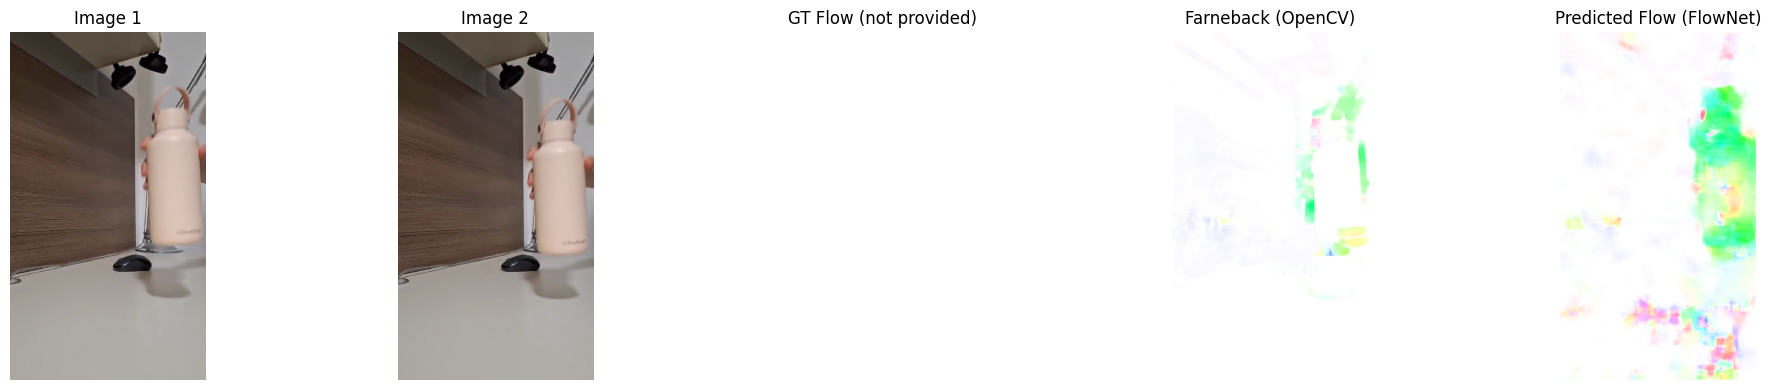

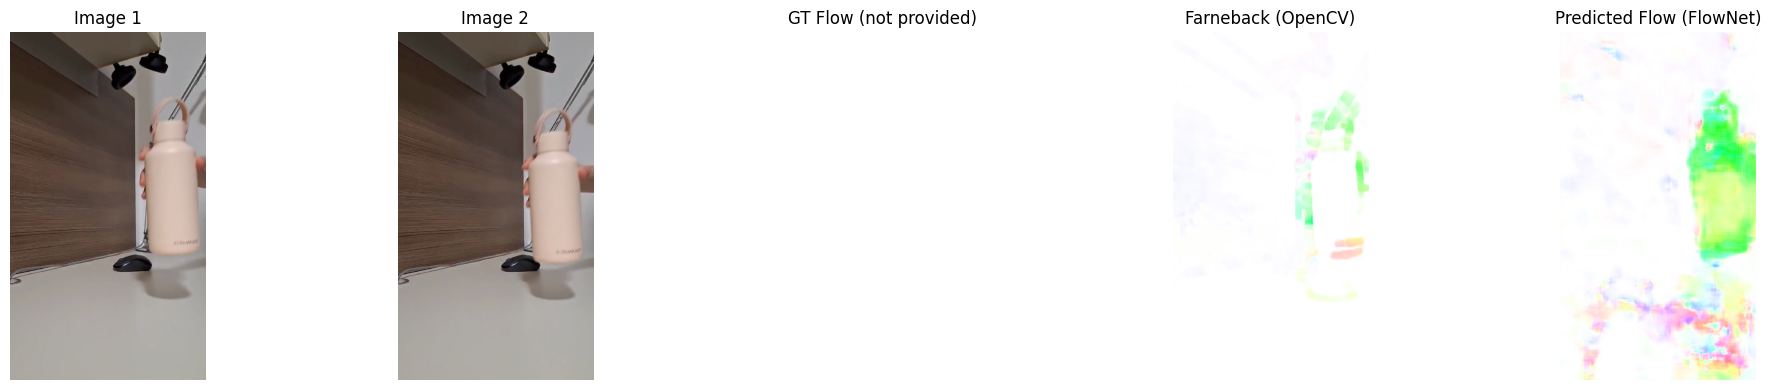

In [ ]:
mine_video_frames_path = "./video/frames"

for i in range(17):
    add_zero_1 = ""
    add_zero_2 = ""
    if i < 10:
        add_zero_1 = "0"
    if i+1 < 10:
        add_zero_2 = "0"
    
    img1_path = os.path.join(mine_video_frames_path, f"frame_000{add_zero_1}{i}.png")
    img2_path = os.path.join(mine_video_frames_path, f"frame_000{add_zero_2}{i+1}.png")
    # flow_path = os.path.join(mine_video_frames_path, f"frame_000{i}{add_zero}_flow.flo")
    visualize_val_sample_from_paths(model_test, img1_path, img2_path, flow_path = None, device = device)
